In [ ]:
import numpy as np, pandas as pd,matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [ ]:

x, y_true = make_blobs(
    n_samples=40, centers=4,
    cluster_std=1.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(
    x,y_true,
    test_size=0.2,
    random_state=42
)
clf=LogisticRegression()
clf.fit(x_tr,y_tr)
print(f'supervised accuracy:{ clf.score(x_te,y_te):.2%}')


supervised accuracy:100.00%


In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_labels=kmeans.fit_predict(x)
print('cluster assignemnts(first 10):',cluster_labels[:10])

cluster assignemnts(first 10): [2 2 0 3 2 2 1 2 0 0]


In [ ]:
import numpy as np,matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


Iter 1: centre moved by 6.2785
Iter 2: centre moved by 3.6678
Iter 3: centre moved by 0.0000
→ Converged!


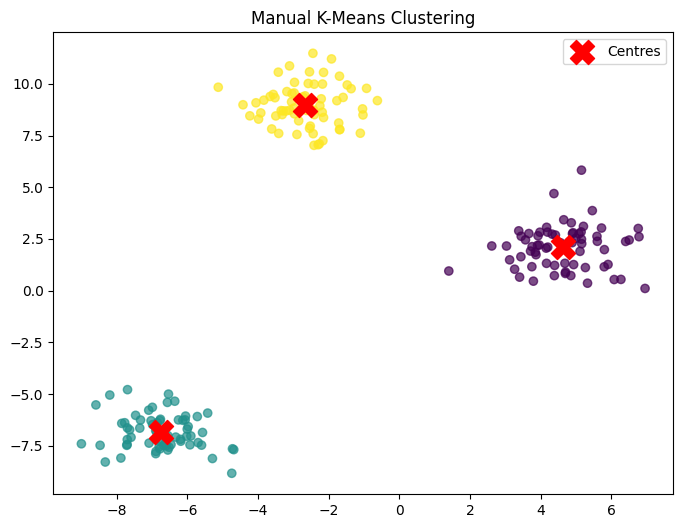

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def manual_kmeans(X, k=3, max_iter=100, random_state=42):

    rng = np.random.default_rng(random_state)


    centres = X[rng.choice(len(X), k, replace=False)]

    for iteration in range(max_iter):


        dists = np.linalg.norm(
            X[:, np.newaxis] - centres,
            axis=2
        )

        labels = np.argmin(dists, axis=1)


        new_centres = np.array([
            X[labels == k_].mean(axis=0)
            for k_ in range(k)
        ])

        print(
            f"Iter {iteration+1}: centre moved by "
            f"{np.linalg.norm(new_centres - centres):.4f}"
        )

        if np.allclose(centres, new_centres):
            print("→ Converged!")
            break

        centres = new_centres

    return labels, centres



X, _ = make_blobs(
    n_samples=200,
    centers=3,
    random_state=42
)


labels, centres = manual_kmeans(X, k=3)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centres[:, 0],
    centres[:, 1],
    c="red",
    s=300,
    marker="X",
    label="Centres"
)

plt.title("Manual K-Means Clustering")
plt.legend()
plt.show()